# 02 — Calibration report

Walk-forward evaluation of the pre-game and live models, including the
comparison against the de-vigged market. This notebook *runs* the same
evaluation `make repro` runs — nothing here is a second implementation.

Takes a couple of minutes (it trains the walk-forward models from scratch).

In [1]:
%config InlineBackend.figure_format = "retina"
import matplotlib.pyplot as plt
import numpy as np

from engine.data.store import Store

store = Store("sqlite:///../data/engine.db")

In [2]:
from engine.models.evaluation import run_pregame_evaluation

pregame = run_pregame_evaluation(store, reports_dir=__import__("pathlib").Path("../reports"))
for block in pregame.full_test:
    print(f"{block.name:32s} n={block.n:5d}  brier={block.brier:.4f}  "
          f"logloss={block.logloss:.4f}  ece={block.ece:.4f}")

2026-07-07 13:15:36 [info     ] feature rows built             total=5291


2026-07-07 13:15:39 [info     ] summary written                path=../reports/pregame_summary.md


Elo                              n= 1326  brier=0.2108  logloss=0.6120  ece=0.0657
GBM (isotonic-calibrated)        n= 1326  brier=0.2120  logloss=0.6127  ece=0.0306
constant p=0.556                 n= 1326  brier=0.2469  logloss=0.6869  ece=0.0000


The GBM's Brier ties Elo; its win is calibration (ECE). On the market-covered
subset the bootstrap interval is the takeaway:

In [3]:
for block in pregame.market_subset:
    print(f"{block.name:32s} n={block.n:5d}  brier={block.brier:.4f}")
point, lo, hi = pregame.gbm_vs_market_brier
print(f"\nGBM − market Brier: {point:+.4f}  (95% CI [{lo:+.4f}, {hi:+.4f}])")
print("=> not distinguishable" if lo <= 0 <= hi else "=> distinguishable")

Market (de-vigged mid)           n=   42  brier=0.2366
GBM (isotonic-calibrated)        n=   42  brier=0.2260
Elo                              n=   42  brier=0.2257

GBM − market Brier: -0.0106  (95% CI [-0.0475, +0.0244])
=> not distinguishable


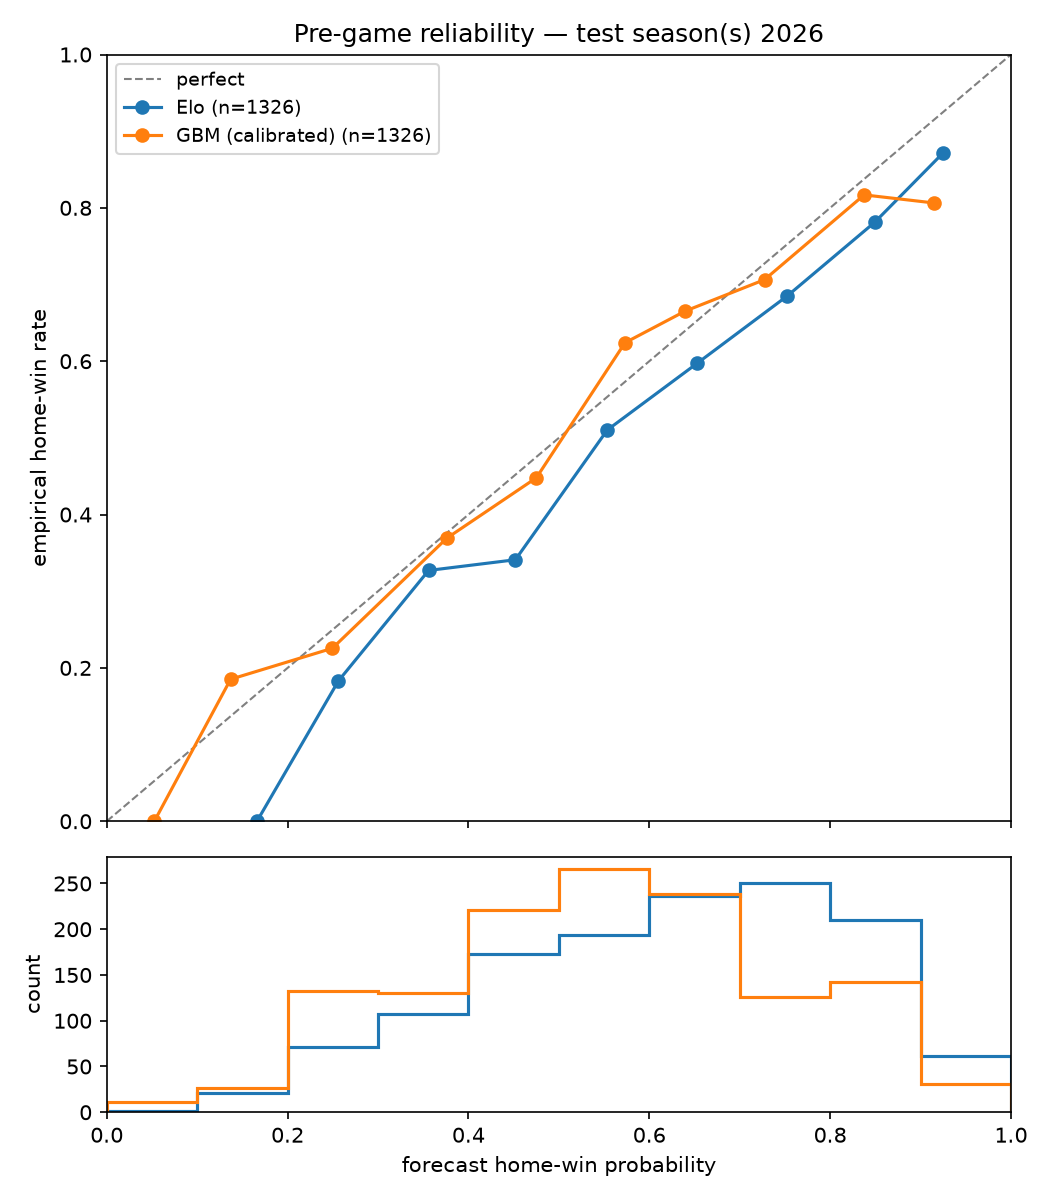

In [4]:
from IPython.display import Image

Image("../reports/calibration_pregame.png", width=640)

## Live in-game model

In [5]:
from engine.models.live_evaluation import run_live_evaluation

live = run_live_evaluation(store, reports_dir=__import__("pathlib").Path("../reports"))
for name, n, brier, ll, ece in live.full_metrics:
    print(f"{name:32s} n={n:,}  brier={brier:.4f}  ece={ece:.4f}")
point, lo, hi = live.diff_ci
print(f"\nvs market on {live.joined_n_snapshots:,} snapshots / {live.joined_n_games} games: "
      f"model {live.model_brier:.4f}, market {live.market_brier:.4f}, "
      f"diff {point:+.4f} CI [{lo:+.4f}, {hi:+.4f}]")

2026-07-07 13:15:45 [info     ] live dataset built             snapshots=2447012


2026-07-07 13:16:28 [info     ] live summary written           path=../reports/live_summary.md


Live WP model (calibrated)       n=642,889  brier=0.1514  ece=0.0106
Pre-game prior only (Elo)        n=642,889  brier=0.2119  ece=0.0655

vs market on 19,350 snapshots / 42 games: model 0.1855, market 0.1776, diff +0.0079 CI [-0.0138, +0.0293]


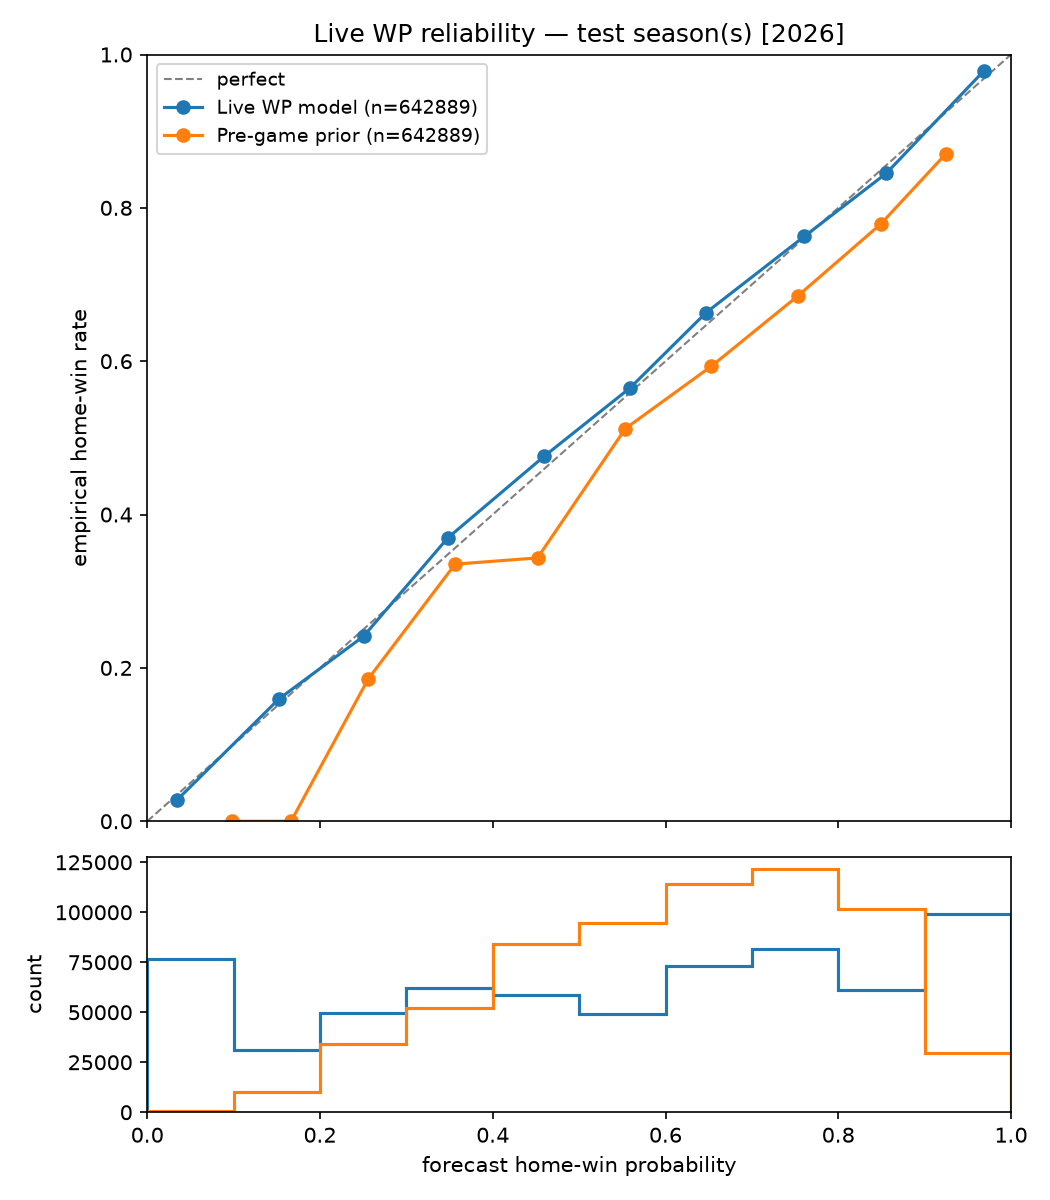

In [6]:
from IPython.display import Image

Image("../reports/calibration_live.png", width=640)

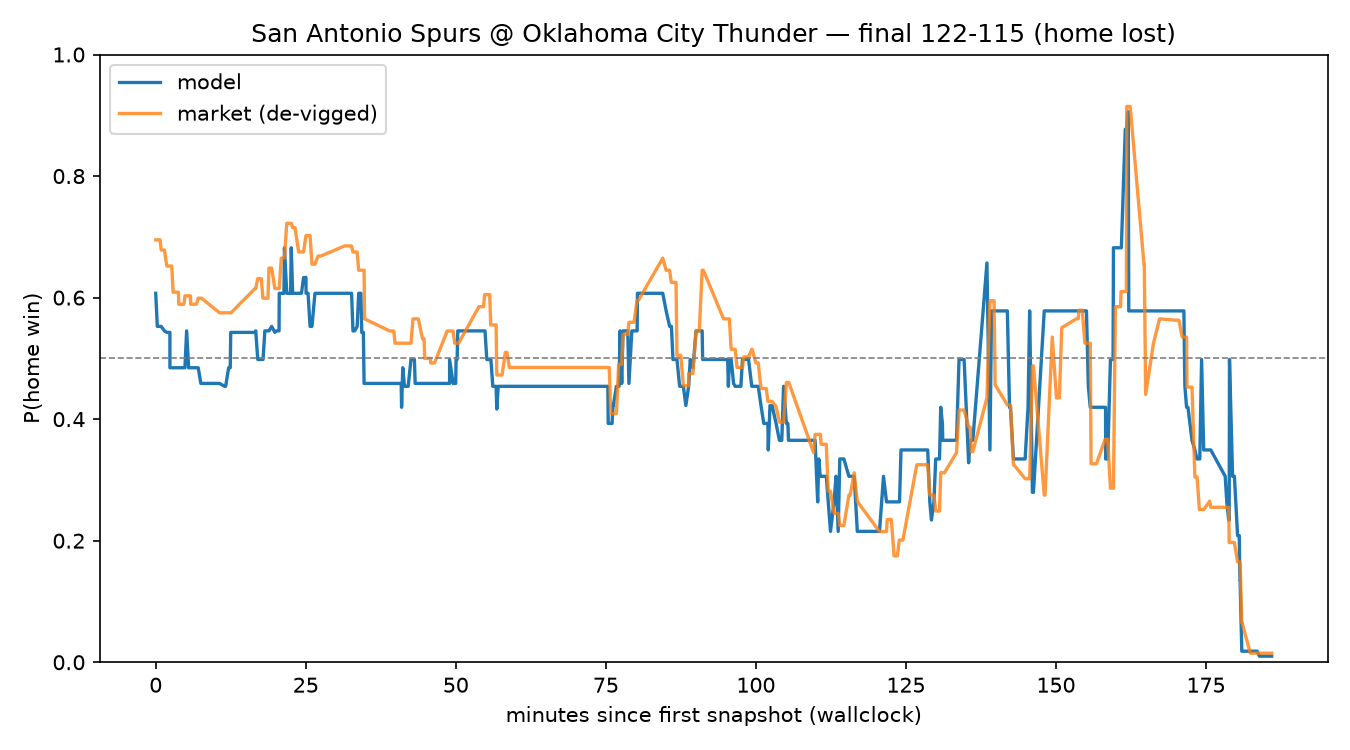

In [7]:
Image("../reports/live_game_example.png", width=720)